In [21]:
# ===============================
# ZINC22 sample molecule fetcher
# Jupyter notebook ready
# ===============================

import json
import requests
import pandas as pd
from pprint import pprint
from io import StringIO

# Optional visualization
try:
    from rdkit import Chem
    from rdkit.Chem import Draw
    RDKit_AVAILABLE = True
except ImportError:
    RDKit_AVAILABLE = False

## Configuration

Base URL, default output fields and HTTP headers used for all requests.

In [22]:
BASE_URL = "https://cartblanche22.docking.org"

# Valid output_fields for the by-id endpoint (from cartblanche22 docs):
#   catalogs, smiles, sub_id, tranche, tranche_details, zinc_id
# Note: supplier_code is NOT a top-level field; it lives nested inside catalogs[].
# The /substance/random endpoint ignores output_fields and always returns
# (tranche, zincid, SMILES); we normalize column names downstream.
DEFAULT_OUTPUT_FIELDS = ",".join([
    "zinc_id",
    "smiles",
    "sub_id",
    "tranche",
    "tranche_details",
    "catalogs",
])

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Jupyter Notebook; ZINC22 exploration script)",
    "Accept": "application/json, text/plain, */*",
}

POLL_INTERVAL_SEC = 2
POLL_MAX_WAIT_SEC = 180

## Helpers: HTTP request and response parsing

In [23]:
def make_request(url, method="GET", params=None, data=None, timeout=60):
    """
    Send request and return response object.
    """
    if method.upper() == "GET":
        resp = requests.get(url, params=params, headers=HEADERS, timeout=timeout)
    else:
        resp = requests.post(url, data=data, headers=HEADERS, timeout=timeout)

    resp.raise_for_status()
    return resp

In [24]:
def parse_response(resp):
    """
    Try parsing API response as JSON first.
    If not JSON, try CSV/TSV/plain text parsing.
    """
    content_type = resp.headers.get("Content-Type", "").lower()
    text = resp.text.strip()

    # 1) Try JSON directly
    try:
        return resp.json(), "json"
    except Exception:
        pass

    # 2) Try plain text containing JSON
    try:
        return json.loads(text), "json_text"
    except Exception:
        pass

    # 3) Try TSV/CSV-like parsing
    # Detect tab-separated
    if "\t" in text:
        try:
            df = pd.read_csv(StringIO(text), sep="\t")
            return df.to_dict(orient="records"), "tsv"
        except Exception:
            pass

    # Detect comma-separated
    lines = text.splitlines()
    if len(lines) >= 2 and "," in lines[0]:
        try:
            df = pd.read_csv(StringIO(text))
            return df.to_dict(orient="records"), "csv"
        except Exception:
            pass

    # 4) Fallback: raw text lines
    return [{"raw_text": line} for line in lines if line.strip()], "text"

## Async task handling

The CartBlanche22 API is asynchronous: submitting to `/substance/random.txt`,
`/substances.txt`, etc. returns `{"task": "<uuid>"}` immediately. The actual
molecule data is fetched by polling a status endpoint until it reports
`status: "SUCCESS"`. Two endpoint shapes are used:

- Random sampling: `GET /substance/random/{task_id}.txt` returns
  `{"status": "...", "result": "tranche zincid SMILES\n<row>\n..."}` (a space
  separated text block).
- ZINC IDs / SMILES / catitems searches: `GET /search/result/{task_id}` returns
  `{"status": "...", "result": {"zinc22": [...], "zinc22_missing": [...], ...}}`.

In [25]:
import time


def extract_task_id(submission):
    """
    Given a parsed submission response, pull out the task UUID.
    Accepts either a dict ({"task": "..."}) or a list of dicts.
    """
    if isinstance(submission, list):
        if not submission:
            raise RuntimeError("Submission response was an empty list.")
        submission = submission[0]
    if not isinstance(submission, dict) or "task" not in submission:
        raise RuntimeError(
            f"Expected submission to contain a 'task' field, got: {submission!r}"
        )
    return submission["task"]


def poll_task(task_id, result_url_template,
              interval=POLL_INTERVAL_SEC, max_wait=POLL_MAX_WAIT_SEC,
              verbose=True):
    """
    Poll an async cartblanche22 task until it finishes.
    
    result_url_template: full URL template containing '{task_id}', e.g.
        f"{BASE_URL}/substance/random/{{task_id}}.txt"
        f"{BASE_URL}/search/result/{{task_id}}"
    
    Returns the parsed 'result' field on SUCCESS.
    Raises RuntimeError on FAILURE/ERROR or timeout.
    """
    url = result_url_template.format(task_id=task_id)
    deadline = time.time() + max_wait
    last_status = None

    while time.time() < deadline:
        resp = make_request(url, method="GET")
        text = resp.text.strip()
        if not text:
            if verbose:
                print(f"  [poll] empty body, waiting {interval}s...")
            time.sleep(interval)
            continue

        try:
            payload = resp.json()
        except Exception:
            try:
                payload = json.loads(text)
            except Exception:
                raise RuntimeError(
                    f"Could not parse poll response as JSON: {text[:200]!r}"
                )

        status = (payload.get("status") or "").upper()
        if status != last_status and verbose:
            print(f"  [poll] task {task_id[:8]}... status={status or '<empty>'}")
            last_status = status

        if status == "SUCCESS":
            return payload.get("result")
        if status in {"FAILURE", "ERROR"}:
            raise RuntimeError(
                f"Task {task_id} ended with status={status}: "
                f"{payload.get('message') or payload.get('result')}"
            )
        time.sleep(interval)

    raise TimeoutError(
        f"Task {task_id} did not complete within {max_wait}s "
        f"(last status: {last_status})"
    )


def parse_random_result_text(result_text):
    """
    The random endpoint returns a single string like:
        "tranche zincid SMILES\nH29P420 ZINCtM...... CCC...\n..."
    Parse it into a list of dicts and normalize column names so the rest of
    the notebook (which expects 'zinc_id'/'smiles') keeps working.
    """
    if not isinstance(result_text, str) or not result_text.strip():
        return []

    lines = [ln for ln in result_text.splitlines() if ln.strip()]
    if not lines:
        return []

    header = lines[0].split()
    rename = {"zincid": "zinc_id", "SMILES": "smiles"}
    header = [rename.get(h, h) for h in header]

    records = []
    for ln in lines[1:]:
        parts = ln.split(None, len(header) - 1)
        if len(parts) < len(header):
            parts += [None] * (len(header) - len(parts))
        records.append(dict(zip(header, parts)))
    return records

## Fetch functions

In [26]:
def fetch_random_molecules(count=5, subset=None, max_wait=POLL_MAX_WAIT_SEC):
    """
    Fetch random molecules from ZINC22.

    Flow:
        1. POST /substance/random.txt with count (and optional subset)
           -> {"task": "<uuid>"}
        2. Poll GET /substance/random/<task_id>.txt until status == SUCCESS
           -> {"status": "SUCCESS", "result": "<header>\\n<row>\\n..."}
        3. Parse the space-separated 'result' string and normalize columns
           ('zincid' -> 'zinc_id', 'SMILES' -> 'smiles').

    Note: this endpoint does not honor output_fields; it always returns
    (tranche, zincid, SMILES).
    """
    submit_url = f"{BASE_URL}/substance/random.txt"
    data = {"count": count}
    if subset:
        data["subset"] = subset

    resp = make_request(submit_url, method="POST", data=data)
    submission, _ = parse_response(resp)
    task_id = extract_task_id(submission)
    print(f"Submitted random task: {task_id}")

    result_text = poll_task(
        task_id,
        result_url_template=f"{BASE_URL}/substance/random/{{task_id}}.txt",
        max_wait=max_wait,
    )

    records = parse_random_result_text(result_text)
    print(f"Random task SUCCESS -> {len(records)} molecule(s).")
    return records

In [27]:
def fetch_by_zinc_ids(zinc_ids, output_fields=DEFAULT_OUTPUT_FIELDS,
                      max_wait=POLL_MAX_WAIT_SEC, return_missing=False):
    """
    Fetch molecule records by one or more ZINC IDs.

    Flow:
        1. POST /substances.json with zinc_ids and output_fields
           -> {"task": "<uuid>"}
        2. Poll GET /search/result/<task_id> until status == SUCCESS
           -> {"status": "SUCCESS",
                "result": {"zinc22": [...], "zinc22_missing": [...], ...}}
        3. Return the zinc22 list of dicts (optionally also the missing-ids list).

    Accepts:
        zinc_ids = ["ZINC....", "ZINC...."]  or comma-separated string
    """
    submit_url = f"{BASE_URL}/substances.json"

    if isinstance(zinc_ids, (list, tuple)):
        zinc_ids = ",".join(zinc_ids)

    data = {"zinc_ids": zinc_ids}
    if output_fields:
        data["output_fields"] = output_fields

    resp = make_request(submit_url, method="POST", data=data)
    submission, _ = parse_response(resp)
    task_id = extract_task_id(submission)
    print(f"Submitted zinc-id task: {task_id}")

    result = poll_task(
        task_id,
        result_url_template=f"{BASE_URL}/search/result/{{task_id}}",
        max_wait=max_wait,
    )

    if isinstance(result, dict):
        records = result.get("zinc22", []) or []
        missing = result.get("zinc22_missing", []) or []
    elif isinstance(result, list):
        records, missing = result, []
    else:
        records, missing = [], []

    print(f"By-ID task SUCCESS -> {len(records)} molecule(s), "
          f"{len([m for m in missing if m])} missing.")

    if return_missing:
        return records, missing
    return records

## Utilities: normalize, inspect, draw

In [28]:
def normalize_records(records):
    """
    Convert list of dict-like molecule records into a flat pandas DataFrame.
    Nested dict/list fields are preserved as JSON strings for easy viewing.
    """
    if not isinstance(records, list):
        records = [records]

    cleaned = []
    for rec in records:
        if not isinstance(rec, dict):
            cleaned.append({"value": str(rec)})
            continue

        row = {}
        for k, v in rec.items():
            if isinstance(v, (dict, list)):
                row[k] = json.dumps(v, ensure_ascii=False)
            else:
                row[k] = v
        cleaned.append(row)

    df = pd.DataFrame(cleaned)
    return df

In [29]:
def inspect_record_features(records, max_records=3):
    """
    Print keys present in sample records so you can see
    which fields/features are available per molecule.
    """
    if not isinstance(records, list):
        records = [records]

    print("=" * 80)
    print(f"Inspecting up to {min(len(records), max_records)} records")
    print("=" * 80)

    all_keys = set()
    for i, rec in enumerate(records[:max_records], start=1):
        print(f"\n--- Record {i} ---")
        if isinstance(rec, dict):
            pprint(rec)
            all_keys.update(rec.keys())
        else:
            print(rec)

    print("\n" + "=" * 80)
    print("All keys observed across inspected records:")
    print(sorted(all_keys))
    print("=" * 80)

In [30]:
def draw_molecules_from_df(df, smiles_col="smiles", id_col="zinc_id", max_mols=8):
    """
    Draw molecules using RDKit if available.
    """
    if not RDKit_AVAILABLE:
        print("RDKit is not installed. Skipping molecule drawing.")
        return None

    mols = []
    legends = []

    for _, row in df.head(max_mols).iterrows():
        smiles = row.get(smiles_col)
        mol_id = str(row.get(id_col, ""))

        if pd.isna(smiles) or not smiles:
            continue

        mol = Chem.MolFromSmiles(str(smiles))
        if mol is not None:
            mols.append(mol)
            legends.append(mol_id)

    if not mols:
        print("No valid SMILES found for drawing.")
        return None

    img = Draw.MolsToGridImage(mols, legends=legends, molsPerRow=4, subImgSize=(250, 250))
    return img

## Example workflow

### Step 1: Fetch a few random molecules from ZINC22

In [31]:
print("STEP 1: Fetch a few random molecules from ZINC22")
random_records = fetch_random_molecules(count=5)

STEP 1: Fetch a few random molecules from ZINC22
Submitted random task: ecc635e2-edf4-401d-8bca-07ae14ca0a3f
  [poll] task ecc635e2... status=SUCCESS
Random task SUCCESS -> 5 molecule(s).


### Step 2: Inspect raw returned records and keys/features

In [32]:
print("STEP 2: Inspect raw returned records and keys/features")
inspect_record_features(random_records, max_records=3)

STEP 2: Inspect raw returned records and keys/features
Inspecting up to 3 records

--- Record 1 ---
{'smiles': 'CC(C)OCC(=O)N[C@@H]1CN(C(=O)c2cccc3c2nnn3C)C[C@H]1S(C)(=O)=O',
 'tranche': 'H29M000',
 'zinc_id': 'ZINCt500001cCRwq'}

--- Record 2 ---
{'smiles': 'COC(=O)NC(C)(C)C(=O)NCC(C)(C)CN(C)C(=O)C[C@@H]1OCCOC1(C)C',
 'tranche': 'H29P130',
 'zinc_id': 'ZINCtj00000ryfpO'}

--- Record 3 ---
{'smiles': 'CC(=O)OC[C@H](CO)NC(=O)C1=C[C@]2(CCN(C(=O)C(C)C)C2)C1',
 'tranche': 'H24P020',
 'zinc_id': 'ZINCo800000HLhZR'}

All keys observed across inspected records:
['smiles', 'tranche', 'zinc_id']


### Step 3: Convert to DataFrame

In [33]:
print("STEP 3: Convert to DataFrame")
df_random = normalize_records(random_records)
display(df_random)

STEP 3: Convert to DataFrame


,tranche,zinc_id,smiles
0,H29M000,ZINCt500001cCRwq,CC(C)OCC(=O)N[C@@H]1CN(C(=O)c2cccc3c2nnn3C)C[C...
1,H29P130,ZINCtj00000ryfpO,COC(=O)NC(C)(C)C(=O)NCC(C)(C)CN(C)C(=O)C[C@@H]...
2,H24P020,ZINCo800000HLhZR,CC(=O)OC[C@H](CO)NC(=O)C1=C[C@]2(CCN(C(=O)C(C)...
3,H29P380,ZINCtI00000LdW9X,COCC(C)(C)CNC(=O)C1(Cc2ccc(Cl)cc2)CN(c2ccnc(C)...
4,H28P340,ZINCsE00000krGW1,C[C@H](C(=O)NC1(c2ccccc2)CN(C(=O)C[C@H]2C[C@@H...


### Step 4: If zinc_id values exist, refetch one or two specifically

In [34]:
print("STEP 4: If zinc_id values exist, refetch one or two specifically")
if "zinc_id" in df_random.columns and df_random["zinc_id"].notna().any():
    sample_ids = df_random["zinc_id"].dropna().astype(str).head(2).tolist()
    print("Sample ZINC IDs:", sample_ids)

    specific_records = fetch_by_zinc_ids(sample_ids)
    inspect_record_features(specific_records, max_records=2)

    df_specific = normalize_records(specific_records)
    display(df_specific)
else:
    print("No zinc_id column found in random fetch result.")

STEP 4: If zinc_id values exist, refetch one or two specifically
Sample ZINC IDs: ['ZINCt500001cCRwq', 'ZINCtj00000ryfpO']
Submitted zinc-id task: b776880b-f926-4470-8792-a2597176e2a8
  [poll] task b776880b... status=PROGRESS
  [poll] task b776880b... status=SUCCESS
By-ID task SUCCESS -> 0 molecule(s), 0 missing.
Inspecting up to 0 records

All keys observed across inspected records:
[]


""


### Step 5: Draw molecules if RDKit is installed and SMILES are present

STEP 5: Draw molecules if RDKit is installed and SMILES are present


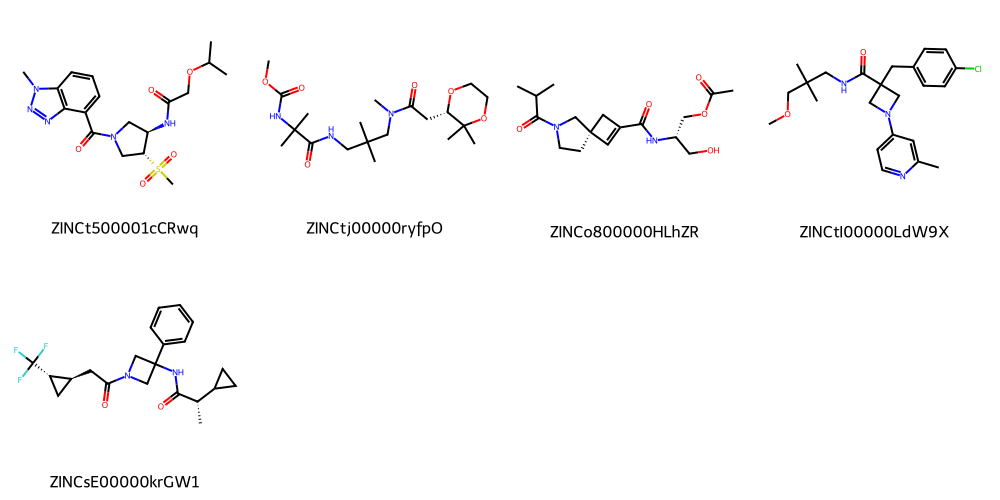

In [35]:
print("STEP 5: Draw molecules if RDKit is installed and SMILES are present")
img = draw_molecules_from_df(df_random)
if img is not None:
    display(img)